## Pairwise similarity

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from itertools import combinations

In [2]:
# Root folders
EXPERIMENTS_ROOT = Path("/data/shared/fsibilla/clean_code/Q0/experiments")
OUTPUT_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/lka_vam")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Models to scan
MODELS = ["cNF", "NF", 
          "TVAE", "CTGAN"]

# Seeds available
SEEDS = [1, 2, 3, 4, 5]

# Dataset subfolder
DATASET_NAME = "lka_vam"

# Variables for pairwise-correlation comparison
TARGET_COLS = [
'education_score', 'log_income', 'space_per_person', 'FES', 'FCS','rCSI'
]

ADM1_COL = "adm1name"

# All variable pairs
PAIR_COLS = list(combinations(TARGET_COLS, 2))

# Synthetic filename (always seed-specific)
SYN_FILENAME = "synthetic_pool.csv"

# Default real filename for models whose training set depends on seed
REAL_FILENAME_TEMPLATE = "full_lka_cleaned_used_for_training_seed{seed}.csv"

# For NF and cNF, the real/training set is fixed across seeds.
# Put here the exact filename that exists in each seed folder or in the results folder.
# If the same file is duplicated inside each seed folder, this code will use seed_1 by default.
FIXED_REAL_MODELS = {"NF", "cNF"}

# First attempt for fixed-real models:
#   /.../<model>/lka_vam/results/fixed_real_filename
FIXED_REAL_FILENAME = "full_lka_cleaned_used_for_training.csv"

OUTPUT_CSV = OUTPUT_DIR / "corrdiff_gen_true.csv"

In [3]:
REFERENCE_REAL_MODEL = "TVAE"   # model from which to read the real/training files
FIXED_REAL_MODELS = {"NF", "cNF"}

def get_real_path(model: str, seed: int):
    """
    Return the correct real/training-set path for a given model and seed.

    Rules:
    - TVAE, CTGAN: use their own seed-specific real file
    - NF, cNF: use the real file from REFERENCE_REAL_MODEL for the same seed
      because the training data are identical across models
    """
    if model in FIXED_REAL_MODELS:
        real_path = (
            EXPERIMENTS_ROOT
            / REFERENCE_REAL_MODEL
            / DATASET_NAME
            / "results"
            / f"seed_{seed}"
            / REAL_FILENAME_TEMPLATE.format(seed=seed)
        )
    else:
        real_path = (
            EXPERIMENTS_ROOT
            / model
            / DATASET_NAME
            / "results"
            / f"seed_{seed}"
            / REAL_FILENAME_TEMPLATE.format(seed=seed)
        )

    if not real_path.exists():
        raise FileNotFoundError(
            f"Real training file not found for model={model}, seed={seed}: {real_path}"
        )

    return real_path

In [4]:
def load_real_and_synth(model: str, seed: int):
    """
    Load real and synthetic data for one model and one seed.
    """
    seed_dir = EXPERIMENTS_ROOT / model / DATASET_NAME / "results" / f"seed_{seed}"

    syn_path = seed_dir / SYN_FILENAME
    real_path = get_real_path(model=model, seed=seed)

    if not syn_path.exists():
        raise FileNotFoundError(f"Synthetic file not found: {syn_path}")
    if not real_path.exists():
        raise FileNotFoundError(f"Real file not found: {real_path}")

    syn_df = pd.read_csv(syn_path)
    real_df = pd.read_csv(real_path)

    needed_cols = [ADM1_COL] + TARGET_COLS
    missing_real = [c for c in needed_cols if c not in real_df.columns]
    missing_syn = [c for c in needed_cols if c not in syn_df.columns]

    if missing_real:
        raise ValueError(f"Missing columns in real_df: {missing_real}")
    if missing_syn:
        raise ValueError(f"Missing columns in syn_df: {missing_syn}")

    real_df = real_df[needed_cols].copy()
    syn_df = syn_df[needed_cols].copy()

    real_df[ADM1_COL] = real_df[ADM1_COL].astype(str)
    syn_df[ADM1_COL] = syn_df[ADM1_COL].astype(str)

    for col in TARGET_COLS:
        real_df[col] = pd.to_numeric(real_df[col], errors="coerce")
        syn_df[col] = pd.to_numeric(syn_df[col], errors="coerce")

    return real_df, syn_df

In [5]:
def safe_pair_corr(df: pd.DataFrame, var1: str, var2: str):
    """
    Pearson correlation on the two columns after pairwise dropna.
    Returns NaN if not enough data or if one variable is constant.
    """
    tmp = df[[var1, var2]].dropna()

    if len(tmp) < 2:
        return np.nan

    x = tmp[var1].to_numpy(dtype=float)
    y = tmp[var2].to_numpy(dtype=float)

    if np.allclose(np.std(x), 0) or np.allclose(np.std(y), 0):
        return np.nan

    return np.corrcoef(x, y)[0, 1]


def compute_corrdiff_by_adm1(real_df: pd.DataFrame, syn_df: pd.DataFrame, model: str, seed: int):
    """
    Compute absolute difference in Pearson correlation between real and synthetic
    data for each variable pair, separately within each adm1.

    Returns a dataframe with columns:
    model, seed, adm1, var1, var2, corr_real, corr_syn, corrdiff
    """
    results = []

    all_adm1 = sorted(
        set(real_df[ADM1_COL].dropna().unique()).intersection(
            set(syn_df[ADM1_COL].dropna().unique())
        )
    )

    for adm1 in all_adm1:
        real_adm = real_df.loc[real_df[ADM1_COL] == adm1]
        syn_adm = syn_df.loc[syn_df[ADM1_COL] == adm1]

        for var1, var2 in PAIR_COLS:
            corr_real = safe_pair_corr(real_adm, var1, var2)
            corr_syn = safe_pair_corr(syn_adm, var1, var2)

            if pd.isna(corr_real) or pd.isna(corr_syn):
                corrdiff = np.nan
            else:
                corrdiff = abs(corr_real - corr_syn)

            results.append({
                "model": model,
                "seed": seed,
                "adm1": adm1,
                "var1": var1,
                "var2": var2,
                "pair": f"{var1}__{var2}",
                "corr_real": corr_real,
                "corr_syn": corr_syn,
                "corrdiff": corrdiff
            })

    return pd.DataFrame(results)

In [6]:
all_results = []

for model in MODELS:
    for seed in SEEDS:
        print(f"Processing model={model}, seed={seed} ...")
        real_df, syn_df = load_real_and_synth(model=model, seed=seed)

        corrdiff_df = compute_corrdiff_by_adm1(
            real_df=real_df,
            syn_df=syn_df,
            model=model,
            seed=seed
        )
        all_results.append(corrdiff_df)

corrdiff_results = pd.concat(all_results, ignore_index=True)

print("Done.")
print("Rows:", len(corrdiff_results))
corrdiff_results.head()

Processing model=cNF, seed=1 ...
Processing model=cNF, seed=2 ...
Processing model=cNF, seed=3 ...
Processing model=cNF, seed=4 ...
Processing model=cNF, seed=5 ...
Processing model=NF, seed=1 ...
Processing model=NF, seed=2 ...
Processing model=NF, seed=3 ...
Processing model=NF, seed=4 ...
Processing model=NF, seed=5 ...
Processing model=TVAE, seed=1 ...
Processing model=TVAE, seed=2 ...
Processing model=TVAE, seed=3 ...
Processing model=TVAE, seed=4 ...
Processing model=TVAE, seed=5 ...
Processing model=CTGAN, seed=1 ...
Processing model=CTGAN, seed=2 ...
Processing model=CTGAN, seed=3 ...
Processing model=CTGAN, seed=4 ...
Processing model=CTGAN, seed=5 ...
Done.
Rows: 2685


,model,seed,adm1,var1,var2,pair,corr_real,corr_syn,corrdiff
0,cNF,1,Central,education_score,log_income,education_score__log_income,0.434822,0.413783,0.021039
1,cNF,1,Central,education_score,space_per_person,education_score__space_per_person,-0.118365,-0.151085,0.032720
2,cNF,1,Central,education_score,FES,education_score__FES,-0.142941,-0.093366,0.049575
3,cNF,1,Central,education_score,FCS,education_score__FCS,0.309211,0.192850,0.116361
4,cNF,1,Central,education_score,rCSI,education_score__rCSI,-0.178791,-0.151451,0.027339


In [7]:
corrdiff_results.to_csv(OUTPUT_CSV, index=False)
print(f"Saved to: {OUTPUT_CSV}")

Saved to: /data/shared/fsibilla/clean_code/Q0/fidelity/lka_vam/corrdiff_gen_true.csv


## Visualize

In [8]:
import matplotlib.pyplot as plt

SEED_TO_PLOT = 1

CORRDIFF_CSV = OUTPUT_DIR / "corrdiff_gen_true.csv"
corrdiff_results = pd.read_csv(CORRDIFF_CSV)

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

In [9]:
def corr_matrix_from_df(df: pd.DataFrame, cols):
    """
    Standard Pearson correlation matrix using pairwise complete observations.
    """
    tmp = df[cols].copy()
    for col in cols:
        tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
    return tmp.corr(method="pearson")


def corrdiff_matrix(real_df: pd.DataFrame, syn_df: pd.DataFrame, cols):
    """
    Absolute difference between real and synthetic correlation matrices.
    """
    corr_real = corr_matrix_from_df(real_df, cols)
    corr_syn = corr_matrix_from_df(syn_df, cols)
    diff = (corr_real - corr_syn).abs()
    return corr_real, corr_syn, diff

In [10]:
corrdiff_avg_seed = (
    corrdiff_results.loc[corrdiff_results["seed"] == SEED_TO_PLOT]
    .groupby(["model", "pair"], as_index=False)["corrdiff"]
    .mean()
    .rename(columns={"corrdiff": "avg_corrdiff_over_adm1"})
)

corrdiff_avg_seed.head()

,model,pair,avg_corrdiff_over_adm1
0,CTGAN,FCS__rCSI,0.197950
1,CTGAN,FES__FCS,0.126093
2,CTGAN,FES__rCSI,0.061146
3,CTGAN,education_score__FCS,0.193034
4,CTGAN,education_score__FES,0.096278


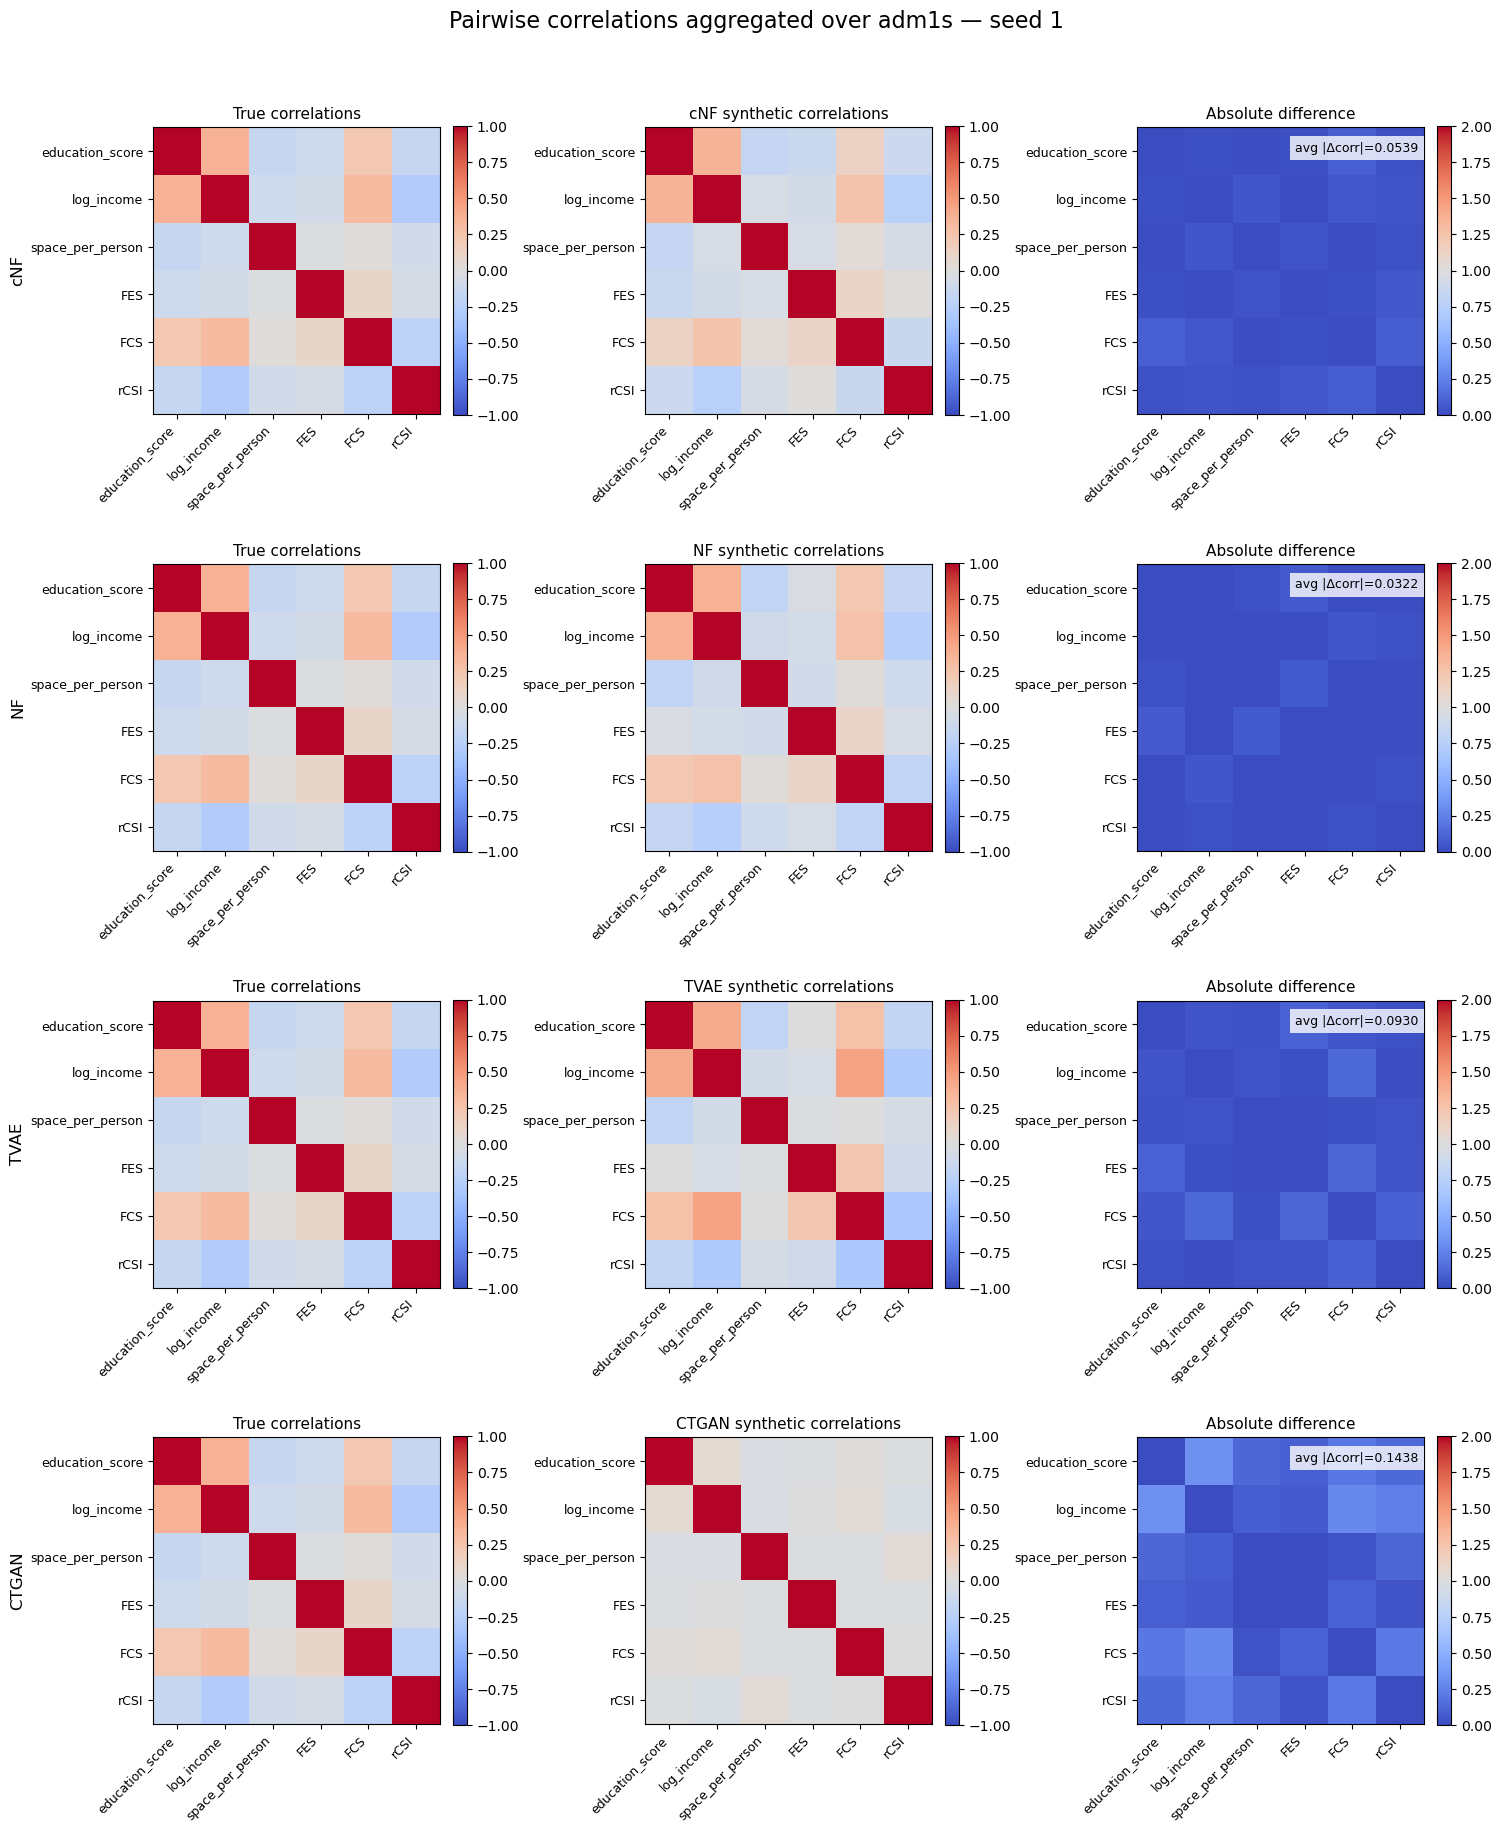

In [11]:
n_models = len(MODELS)

fig, axes = plt.subplots(
    nrows=n_models,
    ncols=3,
    figsize=(15, 4.5 * n_models),
    squeeze=False
)

for i, model in enumerate(MODELS):
    real_df, syn_df = load_real_and_synth(model=model, seed=SEED_TO_PLOT)

    corr_real, corr_syn, corr_abs_diff = corrdiff_matrix(
        real_df=real_df,
        syn_df=syn_df,
        cols=TARGET_COLS
    )

    avg_corrdiff = (
        corrdiff_avg_seed.loc[corrdiff_avg_seed["model"] == model, "avg_corrdiff_over_adm1"]
        .mean()
    )

    mats = [
        (corr_real, "True correlations", -1, 1),
        (corr_syn, f"{model} synthetic correlations", -1, 1),
        (corr_abs_diff, "Absolute difference", 0, 2),
    ]

    for j, (mat, title, vmin, vmax) in enumerate(mats):
        ax = axes[i, j]
        im = ax.imshow(mat.values, vmin=vmin, vmax=vmax, cmap="coolwarm")

        ax.set_xticks(range(len(TARGET_COLS)))
        ax.set_yticks(range(len(TARGET_COLS)))
        ax.set_xticklabels(TARGET_COLS, rotation=45, ha="right", fontsize=9)
        ax.set_yticklabels(TARGET_COLS, fontsize=9)
        ax.set_title(title, fontsize=11)

        if j == 0:
            ax.set_ylabel(model, fontsize=12)

        if j == 2:
            ax.text(
                0.98, 0.95,
                f"avg |Δcorr|={avg_corrdiff:.4f}" if pd.notna(avg_corrdiff) else "avg |Δcorr|=NA",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
            )

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"Pairwise correlations aggregated over adm1s — seed {SEED_TO_PLOT}", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## Baselines

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd

BASELINE_ROOT = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/baselines/lka_vam/bivariate")

CORRDIFF_UB_OUT = OUTPUT_DIR / "corrdiff_ub_true.csv"
CORRDIFF_LB_OUT = OUTPUT_DIR / "corrdiff_lb_true.csv"

In [13]:
def load_true_data(seed: int, reference_model: str = REFERENCE_REAL_MODEL) -> pd.DataFrame:
    """
    Load the true/training dataset for the given seed from a reference model folder.
    """
    real_path = (
        EXPERIMENTS_ROOT
        / reference_model
        / DATASET_NAME
        / "results"
        / f"seed_{seed}"
        / REAL_FILENAME_TEMPLATE.format(seed=seed)
    )

    if not real_path.exists():
        raise FileNotFoundError(f"True dataset not found: {real_path}")

    df = pd.read_csv(real_path)

    required_cols = TARGET_COLS + [ADM1_COL]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in true dataset for seed {seed}: {missing}")

    df = df[required_cols].copy()
    df[ADM1_COL] = df[ADM1_COL].astype(str)

    for col in TARGET_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [14]:
def load_baseline_data(seed: int, baseline_name: str) -> pd.DataFrame:
    """
    Load one baseline dataset for a given seed.
    baseline_name must be 'UB' or 'LB'.
    """
    if baseline_name not in {"UB", "LB"}:
        raise ValueError("baseline_name must be 'UB' or 'LB'")

    path = BASELINE_ROOT / f"seed_{seed}" / f"{baseline_name}.csv"

    if not path.exists():
        raise FileNotFoundError(f"Baseline file not found: {path}")

    df = pd.read_csv(path)

    required_cols = TARGET_COLS + [ADM1_COL]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in baseline {baseline_name}, seed {seed}: {missing}")

    df = df[required_cols].copy()
    df[ADM1_COL] = df[ADM1_COL].astype(str)

    for col in TARGET_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [15]:
def compute_corrdiff_by_adm1(real_df: pd.DataFrame, gen_df: pd.DataFrame, seed: int, model_name: str):
    """
    Compute absolute difference in Pearson correlation between real and generated
    data for each variable pair, separately within each adm1.

    Returns a dataframe with columns:
    model, seed, adm1, var1, var2, corr_real, corr_gen, corrdiff
    """
    results = []

    all_adm1 = sorted(
        set(real_df[ADM1_COL].dropna().unique()).intersection(
            set(gen_df[ADM1_COL].dropna().unique())
        )
    )

    for adm1 in all_adm1:
        real_adm = real_df.loc[real_df[ADM1_COL] == adm1]
        gen_adm = gen_df.loc[gen_df[ADM1_COL] == adm1]

        for var1, var2 in PAIR_COLS:
            corr_real = safe_pair_corr(real_adm, var1, var2)
            corr_gen = safe_pair_corr(gen_adm, var1, var2)

            if pd.isna(corr_real) or pd.isna(corr_gen):
                corrdiff = np.nan
            else:
                corrdiff = abs(corr_real - corr_gen)

            results.append({
                "model": model_name,
                "seed": seed,
                "adm1": adm1,
                "var1": var1,
                "var2": var2,
                "pair": f"{var1}__{var2}",
                "corr_real": corr_real,
                "corr_gen": corr_gen,
                "corrdiff": corrdiff
            })

    return pd.DataFrame(results)

In [16]:
all_ub_results = []

for seed in SEEDS:
    print(f"Processing UB, seed={seed} ...")
    real_df = load_true_data(seed=seed)
    ub_df = load_baseline_data(seed=seed, baseline_name="UB")

    ub_corrdiff_df = compute_corrdiff_by_adm1(
        real_df=real_df,
        gen_df=ub_df,
        seed=seed,
        model_name="UB"
    )
    all_ub_results.append(ub_corrdiff_df)

corrdiff_ub_true = pd.concat(all_ub_results, ignore_index=True)

print("Done UB.")
print("Rows:", len(corrdiff_ub_true))
corrdiff_ub_true.head()

Processing UB, seed=1 ...
Processing UB, seed=2 ...
Processing UB, seed=3 ...
Processing UB, seed=4 ...
Processing UB, seed=5 ...
Done UB.
Rows: 675


,model,seed,adm1,var1,var2,pair,corr_real,corr_gen,corrdiff
0,UB,1,Central,education_score,log_income,education_score__log_income,0.434822,0.456136,0.021314
1,UB,1,Central,education_score,space_per_person,education_score__space_per_person,-0.118365,-0.140147,0.021782
2,UB,1,Central,education_score,FES,education_score__FES,-0.142941,-0.129523,0.013418
3,UB,1,Central,education_score,FCS,education_score__FCS,0.309211,0.306437,0.002774
4,UB,1,Central,education_score,rCSI,education_score__rCSI,-0.178791,-0.184642,0.005851


In [17]:
all_lb_results = []

for seed in SEEDS:
    print(f"Processing LB, seed={seed} ...")
    real_df = load_true_data(seed=seed)
    lb_df = load_baseline_data(seed=seed, baseline_name="LB")

    lb_corrdiff_df = compute_corrdiff_by_adm1(
        real_df=real_df,
        gen_df=lb_df,
        seed=seed,
        model_name="LB"
    )
    all_lb_results.append(lb_corrdiff_df)

corrdiff_lb_true = pd.concat(all_lb_results, ignore_index=True)

print("Done LB.")
print("Rows:", len(corrdiff_lb_true))
corrdiff_lb_true.head()

Processing LB, seed=1 ...


Processing LB, seed=2 ...
Processing LB, seed=3 ...
Processing LB, seed=4 ...
Processing LB, seed=5 ...
Done LB.
Rows: 675


,model,seed,adm1,var1,var2,pair,corr_real,corr_gen,corrdiff
0,LB,1,Central,education_score,log_income,education_score__log_income,0.434822,0.028692,0.406130
1,LB,1,Central,education_score,space_per_person,education_score__space_per_person,-0.118365,0.008751,0.127116
2,LB,1,Central,education_score,FES,education_score__FES,-0.142941,0.012266,0.155206
3,LB,1,Central,education_score,FCS,education_score__FCS,0.309211,0.000623,0.308588
4,LB,1,Central,education_score,rCSI,education_score__rCSI,-0.178791,0.008259,0.187050


In [18]:
corrdiff_ub_true.to_csv(CORRDIFF_UB_OUT, index=False)
corrdiff_lb_true.to_csv(CORRDIFF_LB_OUT, index=False)

print(f"Saved UB EMD table to: {CORRDIFF_UB_OUT}")
print(f"Saved LB EMD table to: {CORRDIFF_LB_OUT}")

Saved UB EMD table to: /data/shared/fsibilla/clean_code/Q0/fidelity/lka_vam/corrdiff_ub_true.csv
Saved LB EMD table to: /data/shared/fsibilla/clean_code/Q0/fidelity/lka_vam/corrdiff_lb_true.csv


## Normalize and visualize

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/lka_vam")

GEN_CORRDIFF_PATH = FIDELITY_DIR / "corrdiff_gen_true.csv"
UB_CORRDIFF_PATH = FIDELITY_DIR / "corrdiff_ub_true.csv"
LB_CORRDIFF_PATH = FIDELITY_DIR / "corrdiff_lb_true.csv"

NORMALIZED_OUT_PATH = FIDELITY_DIR / "corrdiff_gen_true_normalized.csv"

In [20]:
gen_corrdiff = pd.read_csv(GEN_CORRDIFF_PATH)
ub_corrdiff = pd.read_csv(UB_CORRDIFF_PATH)
lb_corrdiff = pd.read_csv(LB_CORRDIFF_PATH)

print("gen_corrdiff shape:", gen_corrdiff.shape)
print("ub_corrdiff shape:", ub_corrdiff.shape)
print("lb_corrdiff shape:", lb_corrdiff.shape)

display(gen_corrdiff.head())
display(ub_corrdiff.head())
display(lb_corrdiff.head())

gen_corrdiff shape: (2685, 9)
ub_corrdiff shape: (675, 9)
lb_corrdiff shape: (675, 9)


,model,seed,adm1,var1,var2,pair,corr_real,corr_syn,corrdiff
0,cNF,1,Central,education_score,log_income,education_score__log_income,0.434822,0.413783,0.021039
1,cNF,1,Central,education_score,space_per_person,education_score__space_per_person,-0.118365,-0.151085,0.032720
2,cNF,1,Central,education_score,FES,education_score__FES,-0.142941,-0.093366,0.049575
3,cNF,1,Central,education_score,FCS,education_score__FCS,0.309211,0.192850,0.116361
4,cNF,1,Central,education_score,rCSI,education_score__rCSI,-0.178791,-0.151451,0.027339


,model,seed,adm1,var1,var2,pair,corr_real,corr_gen,corrdiff
0,UB,1,Central,education_score,log_income,education_score__log_income,0.434822,0.456136,0.021314
1,UB,1,Central,education_score,space_per_person,education_score__space_per_person,-0.118365,-0.140147,0.021782
2,UB,1,Central,education_score,FES,education_score__FES,-0.142941,-0.129523,0.013418
3,UB,1,Central,education_score,FCS,education_score__FCS,0.309211,0.306437,0.002774
4,UB,1,Central,education_score,rCSI,education_score__rCSI,-0.178791,-0.184642,0.005851


,model,seed,adm1,var1,var2,pair,corr_real,corr_gen,corrdiff
0,LB,1,Central,education_score,log_income,education_score__log_income,0.434822,0.028692,0.406130
1,LB,1,Central,education_score,space_per_person,education_score__space_per_person,-0.118365,0.008751,0.127116
2,LB,1,Central,education_score,FES,education_score__FES,-0.142941,0.012266,0.155206
3,LB,1,Central,education_score,FCS,education_score__FCS,0.309211,0.000623,0.308588
4,LB,1,Central,education_score,rCSI,education_score__rCSI,-0.178791,0.008259,0.187050


In [21]:
ub_for_merge = (
    ub_corrdiff[["seed", "adm1", "var1", "var2", "pair", "corrdiff"]]
    .rename(columns={"corrdiff": "corrdiff_ub"})
    .copy()
)

lb_for_merge = (
    lb_corrdiff[["seed", "adm1", "var1", "var2", "pair", "corrdiff"]]
    .rename(columns={"corrdiff": "corrdiff_lb"})
    .copy()
)

In [22]:
corrdiff_norm = (
    gen_corrdiff
    .merge(ub_for_merge, on=["seed", "adm1", "var1", "var2", "pair"], how="left")
    .merge(lb_for_merge, on=["seed", "adm1", "var1", "var2", "pair"], how="left")
    .copy()
)

# denominator
corrdiff_norm["denom"] = corrdiff_norm["corrdiff_lb"] - corrdiff_norm["corrdiff_ub"]

# raw normalized value:
# 0 = UB, 1 = LB
corrdiff_norm["corrdiff_norm_raw"] = np.where(
    corrdiff_norm["denom"].abs() > 1e-12,
    (corrdiff_norm["corrdiff"] - corrdiff_norm["corrdiff_ub"]) / corrdiff_norm["denom"],
    np.nan
)

# clipped version for visualization in [0, 1]
corrdiff_norm["corrdiff_norm"] = corrdiff_norm["corrdiff_norm_raw"].clip(0, 1)

print("Merged shape:", corrdiff_norm.shape)
corrdiff_norm.head()

Merged shape: (2685, 14)


,model,seed,adm1,var1,var2,pair,corr_real,corr_syn,corrdiff,corrdiff_ub,corrdiff_lb,denom,corrdiff_norm_raw,corrdiff_norm
0,cNF,1,Central,education_score,log_income,education_score__log_income,0.434822,0.413783,0.021039,0.021314,0.406130,0.384816,-0.000714,0.000000
1,cNF,1,Central,education_score,space_per_person,education_score__space_per_person,-0.118365,-0.151085,0.032720,0.021782,0.127116,0.105335,0.103839,0.103839
2,cNF,1,Central,education_score,FES,education_score__FES,-0.142941,-0.093366,0.049575,0.013418,0.155206,0.141788,0.255005,0.255005
3,cNF,1,Central,education_score,FCS,education_score__FCS,0.309211,0.192850,0.116361,0.002774,0.308588,0.305815,0.371425,0.371425
4,cNF,1,Central,education_score,rCSI,education_score__rCSI,-0.178791,-0.151451,0.027339,0.005851,0.187050,0.181199,0.118590,0.118590


In [23]:
corrdiff_norm.to_csv(NORMALIZED_OUT_PATH, index=False)
print(f"Saved normalized table to: {NORMALIZED_OUT_PATH}")

Saved normalized table to: /data/shared/fsibilla/clean_code/Q0/fidelity/lka_vam/corrdiff_gen_true_normalized.csv


In [24]:
plot_df = (
    corrdiff_norm
    .groupby(["model", "pair", "adm1"], as_index=False)
    .agg(
        corrdiff_norm_mean=("corrdiff_norm", "mean"),
        corrdiff_norm_std=("corrdiff_norm", "std"),
        n_seeds=("corrdiff_norm", "count")
    )
)

# std can be NaN if only one seed is present
plot_df["corrdiff_norm_std"] = plot_df["corrdiff_norm_std"].fillna(0.0)

print(plot_df.shape)
plot_df.head()

(540, 6)


,model,pair,adm1,corrdiff_norm_mean,corrdiff_norm_std,n_seeds
0,CTGAN,FCS__rCSI,Central,0.914119,0.067295,5
1,CTGAN,FCS__rCSI,Eastern,0.927386,0.048240,5
2,CTGAN,FCS__rCSI,North Central,0.930936,0.114529,5
3,CTGAN,FCS__rCSI,North Western,0.835656,0.230364,5
4,CTGAN,FCS__rCSI,Northern,0.863629,0.183948,5


In [25]:
MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

MODEL_ORDER = ["cNF", "NF", "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in plot_df["model"].unique()]

PAIR_ORDER = [f"{v1}__{v2}" for v1, v2 in PAIR_COLS]
PAIR_ORDER = [p for p in PAIR_ORDER if p in plot_df["pair"].unique()]

print("Models:", MODEL_ORDER)
print("Pairs:", PAIR_ORDER)



Models: ['cNF', 'NF', 'TVAE', 'CTGAN']
Pairs: ['education_score__log_income', 'education_score__space_per_person', 'education_score__FES', 'education_score__FCS', 'education_score__rCSI', 'log_income__space_per_person', 'log_income__FES', 'log_income__FCS', 'log_income__rCSI', 'space_per_person__FES', 'space_per_person__FCS', 'space_per_person__rCSI', 'FES__FCS', 'FES__rCSI', 'FCS__rCSI']


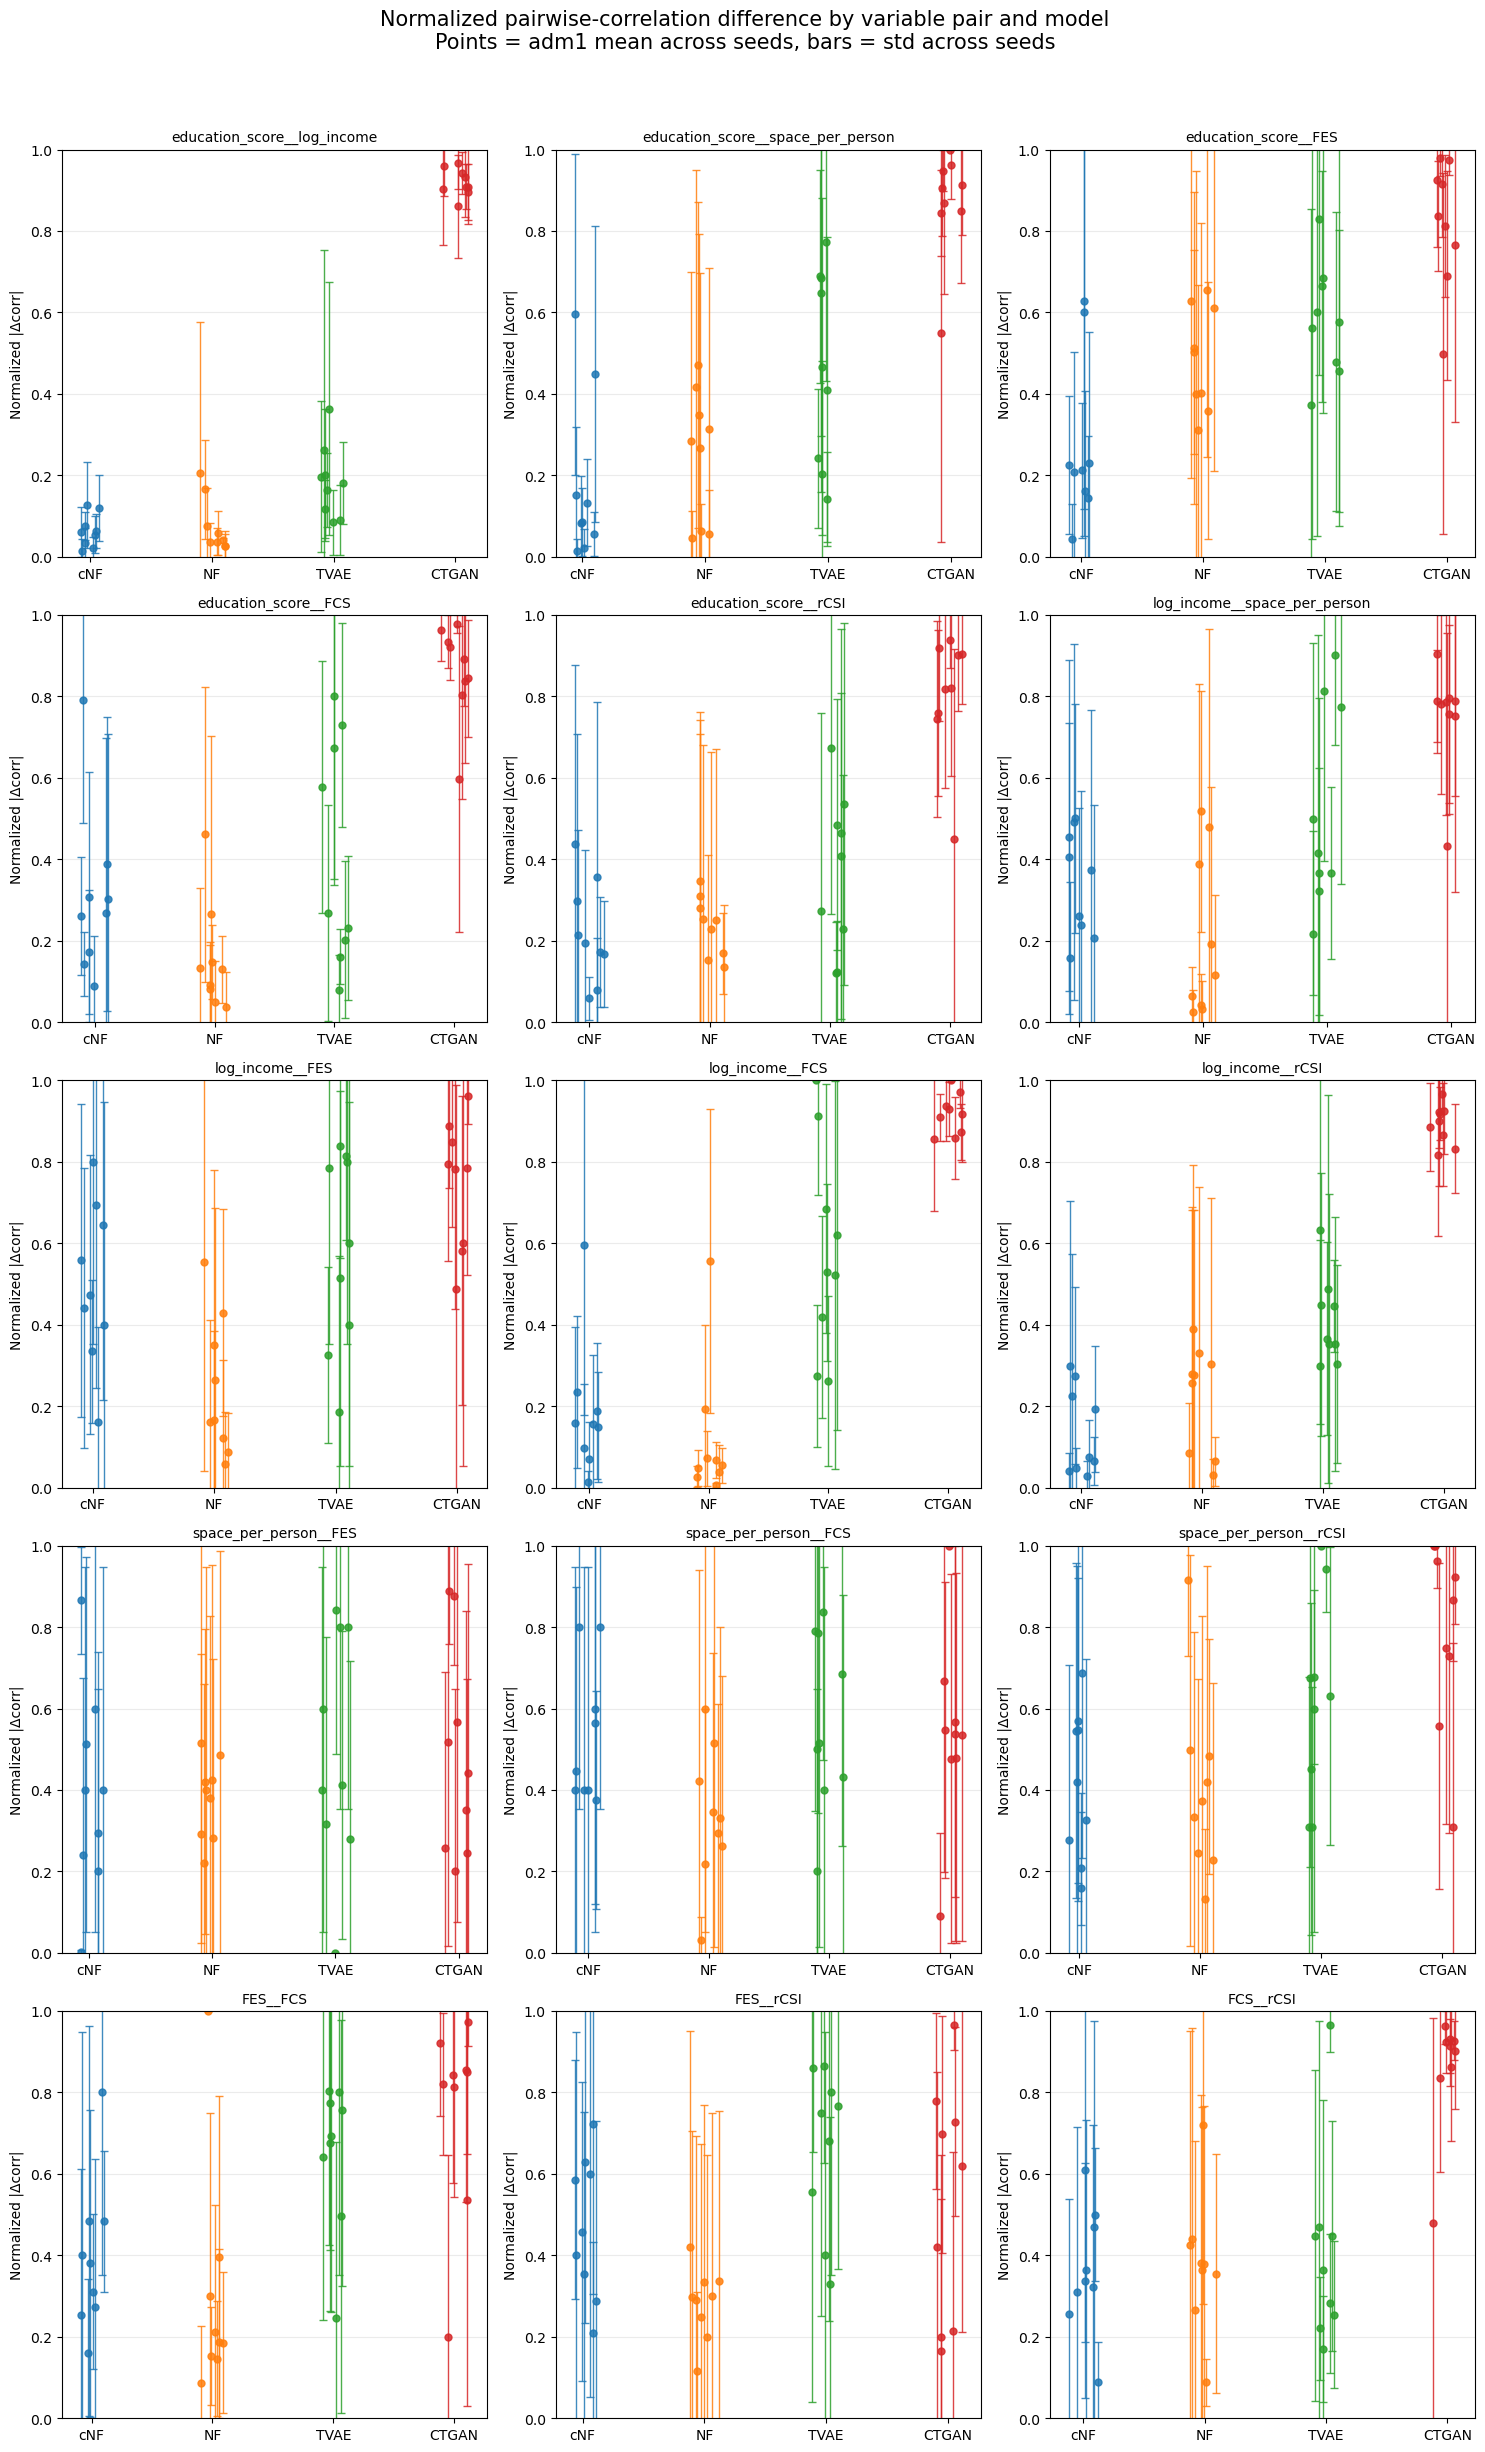

In [26]:
n_pairs = len(PAIR_ORDER)
ncols = 3
nrows = int(np.ceil(n_pairs / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.0 * ncols, 4.8 * nrows),
    squeeze=False
)

rng = np.random.default_rng(12345)

for idx, pair in enumerate(PAIR_ORDER):
    r = idx // ncols
    c = idx % ncols
    ax = axes[r, c]

    sub = plot_df.loc[plot_df["pair"] == pair].copy()

    for x_pos, model in enumerate(MODEL_ORDER):
        sub_m = sub.loc[sub["model"] == model].copy().sort_values("adm1")

        if sub_m.empty:
            continue

        # small horizontal jitter so multiple adm1 points are visible inside each model column
        jitter = rng.uniform(-0.12, 0.12, size=len(sub_m))
        x_vals = x_pos + jitter

        ax.errorbar(
            x_vals,
            sub_m["corrdiff_norm_mean"].to_numpy(),
            yerr=sub_m["corrdiff_norm_std"].to_numpy(),
            fmt="o",
            capsize=3,
            alpha=0.85,
            color=MODEL_COLORS.get(model, "tab:blue"),
            ecolor=MODEL_COLORS.get(model, "tab:blue"),
            markersize=5,
            linewidth=1
        )

    ax.set_title(pair, fontsize=10)
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels(MODEL_ORDER, rotation=0)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Normalized |Δcorr|")
    ax.grid(alpha=0.25, axis="y")

# hide empty panels
for idx in range(n_pairs, nrows * ncols):
    r = idx // ncols
    c = idx % ncols
    axes[r, c].axis("off")

plt.suptitle("Normalized pairwise-correlation difference by variable pair and model\nPoints = adm1 mean across seeds, bars = std across seeds", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

## average on pairs

In [27]:
# Models on x-axis, one scatter per pair (no pair labels)
# Each point = mean over seeds of the adm1-averaged value for that pair
# Error bar = std across seeds

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

MODEL_ORDER = ["cNF", "NF", "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in corrdiff_norm["model"].unique()]

# Step 1: average over adm1 within each seed
pair_seed_df = (
    corrdiff_norm
    .groupby(["model", "seed", "pair"], as_index=False)
    .agg(
        corrdiff_norm_seed_mean=("corrdiff_norm", "mean")
    )
)

# Step 2: mean ± std across seeds, separately for each pair
pair_plot_df = (
    pair_seed_df
    .groupby(["model", "pair"], as_index=False)
    .agg(
        corrdiff_norm_mean=("corrdiff_norm_seed_mean", "mean"),
        corrdiff_norm_std=("corrdiff_norm_seed_mean", "std"),
        n_seeds=("corrdiff_norm_seed_mean", "count"),
    )
)

pair_plot_df["corrdiff_norm_std"] = pair_plot_df["corrdiff_norm_std"].fillna(0.0)

display(pair_plot_df.head())

,model,pair,corrdiff_norm_mean,corrdiff_norm_std,n_seeds
0,CTGAN,FCS__rCSI,0.860139,0.063451,5
1,CTGAN,FES__FCS,0.756883,0.101275,5
2,CTGAN,FES__rCSI,0.532201,0.082090,5
3,CTGAN,education_score__FCS,0.863466,0.062025,5
4,CTGAN,education_score__FES,0.822312,0.084510,5


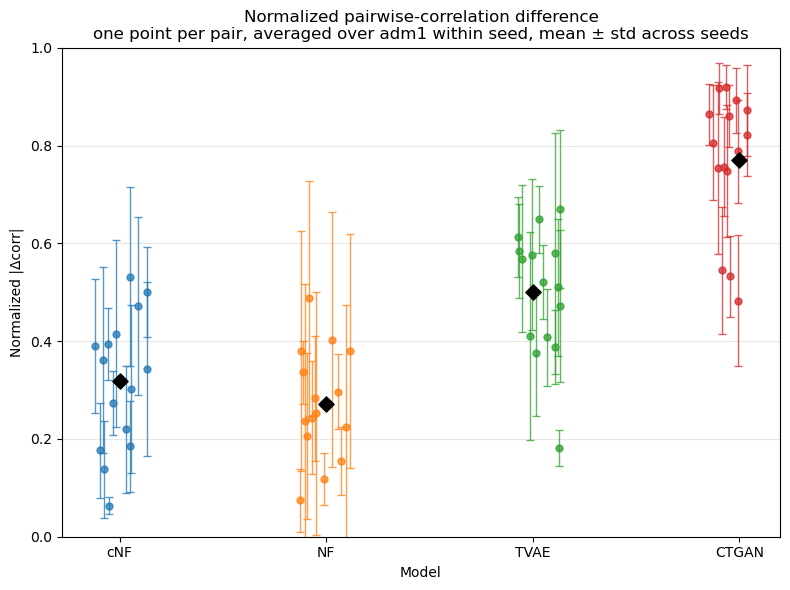

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

rng = np.random.default_rng(12345)

for x_pos, model in enumerate(MODEL_ORDER):
    sub = pair_plot_df.loc[pair_plot_df["model"] == model].copy()

    if sub.empty:
        continue

    # small jitter so points do not overlap completely
    jitter = rng.uniform(-0.15, 0.15, size=len(sub))
    x_vals = x_pos + jitter

    ax.errorbar(
        x_vals,
        sub["corrdiff_norm_mean"].to_numpy(),
        yerr=sub["corrdiff_norm_std"].to_numpy(),
        fmt="o",
        capsize=3,
        alpha=0.75,
        color=MODEL_COLORS.get(model, "gray"),
        ecolor=MODEL_COLORS.get(model, "gray"),
        markersize=5,
        linewidth=1,
    )

    # optional: black marker for the average across pairs
    model_mean = sub["corrdiff_norm_mean"].mean()
    ax.scatter(
        x_pos,
        model_mean,
        marker="D",
        s=60,
        color="black",
        zorder=5,
    )

ax.set_xticks(range(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER)
ax.set_ylim(0, 1)
ax.set_ylabel("Normalized |Δcorr|")
ax.set_xlabel("Model")
ax.set_title("Normalized pairwise-correlation difference\none point per pair, averaged over adm1 within seed, mean ± std across seeds")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()